In [1]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [2]:
pwd

'c:\\Users\\Dell\\Desktop\\FastAPI\\5_ml_model_using_fastAPI'

In [3]:
df=pd.read_csv('.\insurance.csv')

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Dell\AppData\Local\Temp\ipykernel_9132\2477814925.py:1: SyntaxWarning: invalid escape sequence '\i'
  df=pd.read_csv('.\insurance.csv')


In [4]:
df.head()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [5]:
df.sample(5)

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
27,58,111.4,1.78,34.33000,False,Lucknow,private_job,Medium
32,47,113.7,1.90,50.00000,False,Jalandhar,private_job,Medium
39,51,100.6,1.68,11.99000,True,Bangalore,unemployed,High
95,36,52.8,1.57,19.64000,False,Indore,business_owner,Low
99,40,70.0,1.59,28.16664,True,Bangalore,government_job,Low


In [6]:
df['occupation'].unique()

<StringArray>
[       'retired',     'freelancer',        'student', 'government_job',
 'business_owner',     'unemployed',    'private_job']
Length: 7, dtype: str

In [7]:
#feature 1 : bmi
df_feat=df.copy()

In [8]:
df_feat["bmi"]=df_feat["weight"]/(df_feat["height"]**2)

In [9]:
#feature 2: age_group
def age_group(age):
    if age <25:
        return "young"
    elif age <45:
        return "adult"
    elif age<60:
        return "middle_aged"
    return "senior"

In [10]:
df_feat["age_group"]=df_feat["age"].apply(age_group)

In [11]:
#feature 3: Lifestyle Risk
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30:
        return "high"
    elif row["smoker"] and row["bmi"]>27:
        return "medium"
    else:
        return "low"
    

In [12]:
df_feat["lifestyle_risk"] =df_feat.apply(lifestyle_risk, axis=1)

In [13]:
df_feat["lifestyle_risk"]

0        low
1        low
2        low
3       high
4        low
       ...  
95       low
96       low
97       low
98       low
99    medium
Name: lifestyle_risk, Length: 100, dtype: str

In [14]:
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]
     

In [15]:
# Feature 4: City Tier
def city_tier(city):
    if city in tier_1_cities:
        return 1
    elif city in tier_2_cities:
        return 2
    else:
        return 3
     

In [16]:
df_feat["city_tier"] = df_feat["city"].apply(city_tier)

In [17]:

df_feat.drop(columns=['age', 'weight', 'height', 'smoker', 'city'])[['income_lpa', 'occupation', 'bmi', 'age_group', 'lifestyle_risk', 'city_tier', 'insurance_premium_category']].sample(5)
     

,income_lpa,occupation,bmi,age_group,lifestyle_risk,city_tier,insurance_premium_category
72,3.08,retired,35.499527,senior,low,2,High
92,30.00,government_job,18.319942,adult,low,2,Low
12,17.58,freelancer,30.046711,adult,high,2,High
30,32.97,business_owner,29.937519,adult,low,1,Low
68,0.68,student,22.963196,young,low,2,Low


In [18]:
# EDA - Check for missing values
display(df_feat.isnull().sum())

age                           0
weight                        0
height                        0
income_lpa                    0
smoker                        0
city                          0
occupation                    0
insurance_premium_category    0
bmi                           0
age_group                     0
lifestyle_risk                0
city_tier                     0
dtype: int64

In [19]:


# Select features and target
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]
     

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

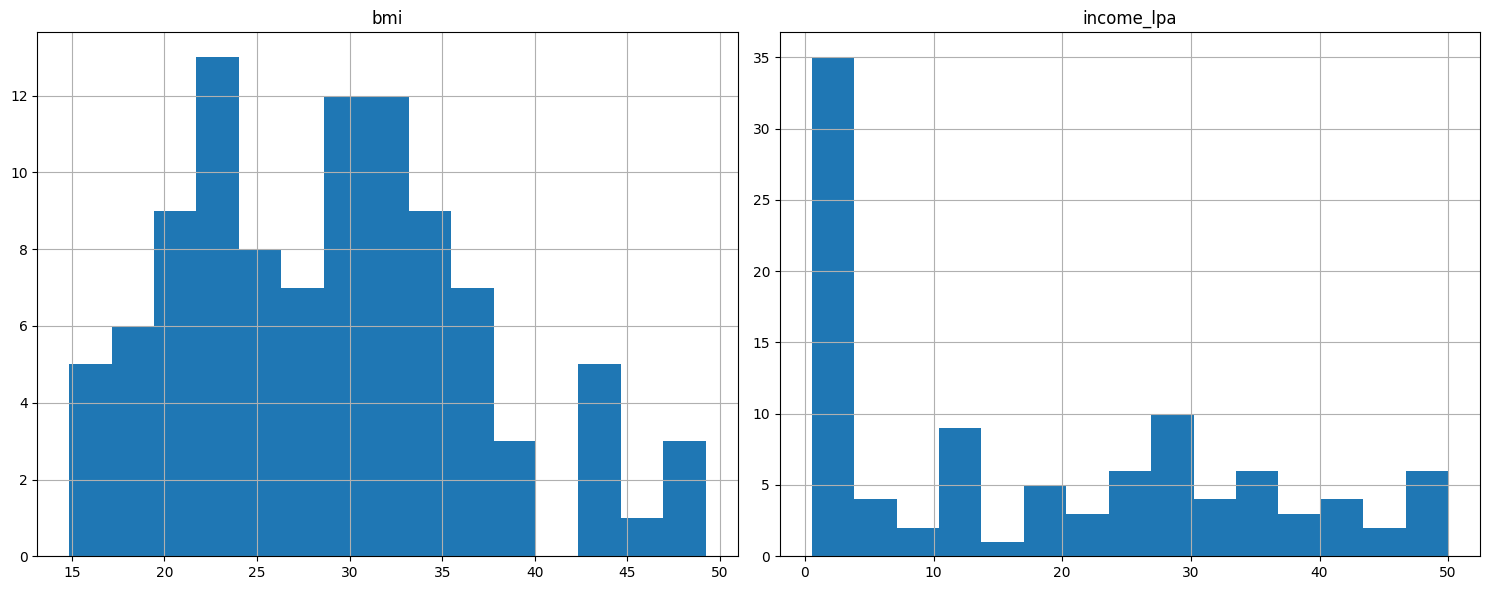

In [21]:
neumarical_features =["bmi","income_lpa"]
df_feat[neumarical_features].hist(bins=15,figsize=(15,6),layout=(1,2))
plt.tight_layout()
plt.show()

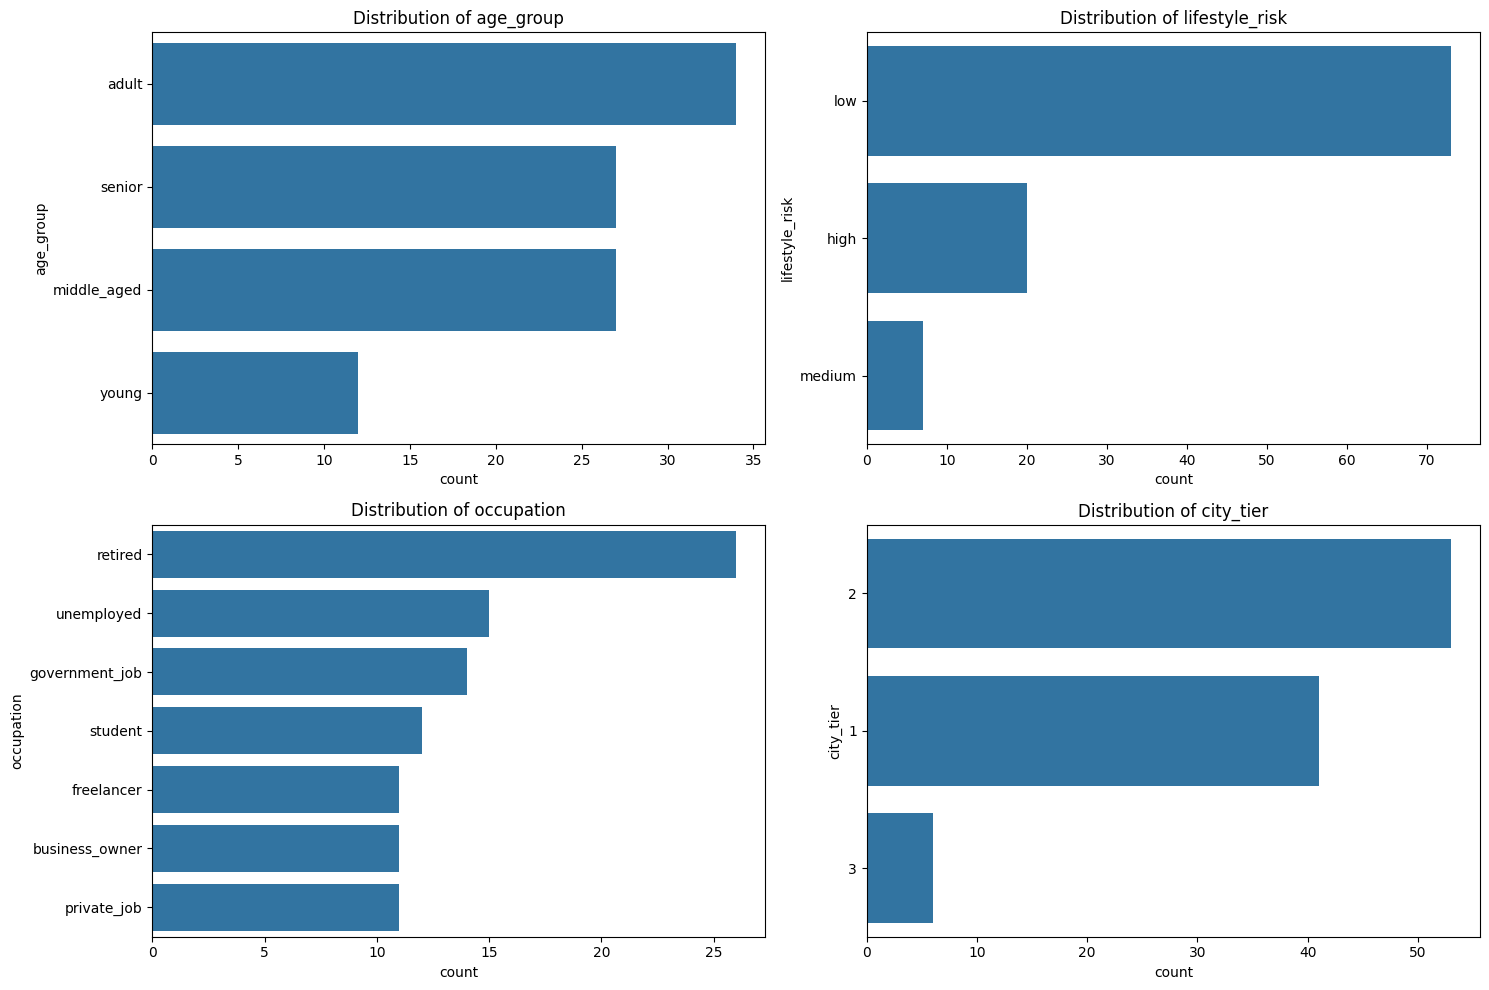

In [22]:
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(y=col, data=df_feat, ax=axes[i], order = df_feat[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()
     

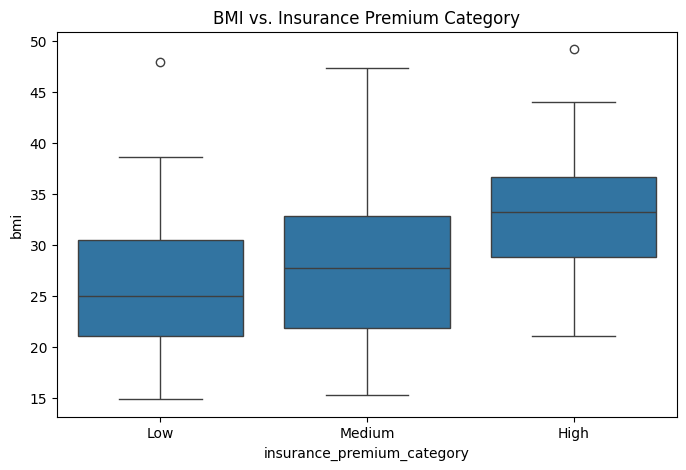

In [23]:


# Explore relationship between BMI and insurance premium category
plt.figure(figsize=(8, 5))
sns.boxplot(x='insurance_premium_category', y='bmi', data=df_feat, order=['Low', 'Medium', 'High'])
plt.title('BMI vs. Insurance Premium Category')
plt.show()

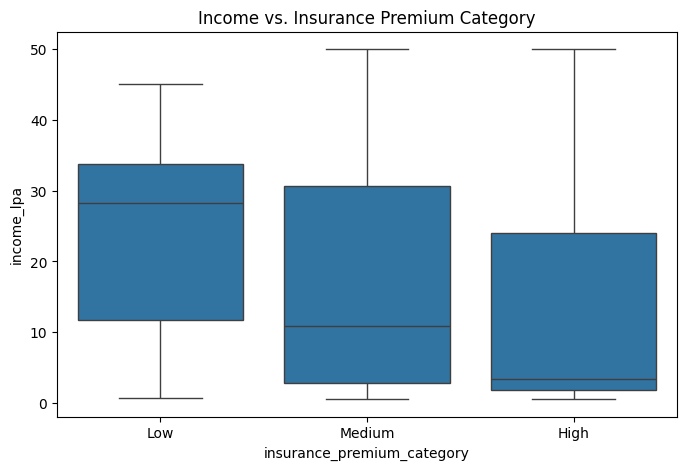

In [24]:
# Explore relationship between income and insurance premium category
plt.figure(figsize=(8, 5))
sns.boxplot(x='insurance_premium_category', y='income_lpa', data=df_feat, order=['Low', 'Medium', 'High'])
plt.title('Income vs. Insurance Premium Category')
plt.show()
     

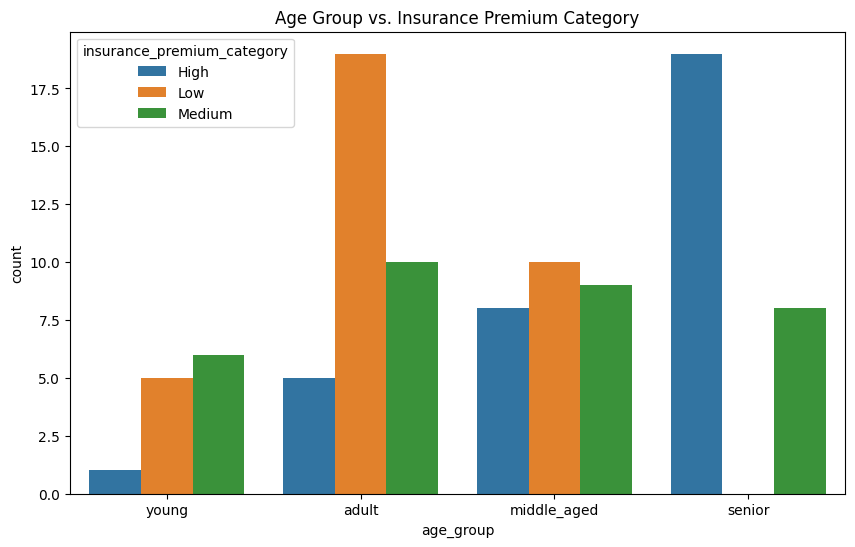

In [25]:

# Explore relationship between age group and insurance premium category
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='insurance_premium_category', data=df_feat, order=['young', 'adult', 'middle_aged', 'senior'])
plt.title('Age Group vs. Insurance Premium Category')
plt.show()
     

In [26]:
"""  FOR MORE EDA analysis 
import plotly.express as px
# Relationship between smoker and insurance premium category
smoker_premium = df_feat.groupby(['smoker', 'insurance_premium_category']).size().reset_index(name='count')
fig = px.bar(smoker_premium, x='smoker', y='count', color='insurance_premium_category',
             title='Insurance Premium Category Distribution by Smoker Status')
fig.show()

# Relationship between city tier and insurance premium category
city_tier_premium = df_feat.groupby(['city_tier', 'insurance_premium_category']).size().reset_index(name='count')
fig = px.bar(city_tier_premium, x='city_tier', y='count', color='insurance_premium_category',
             title='Insurance Premium Category Distribution by City Tier')
fig.show()

# Exploring multiple columns influencing premium (e.g., BMI, Age Group, and Premium)
fig = px.box(df_feat, x='age_group', y='bmi', color='insurance_premium_category',
             title='BMI Distribution by Age Group and Insurance Premium Category')
fig.show()

fig = px.scatter(df_feat, x='income_lpa', y='bmi', color='insurance_premium_category',
                 title='BMI vs. Income colored by Insurance Premium Category',
                 hover_data=['age_group', 'lifestyle_risk', 'occupation', 'city_tier'])
fig.show()
     """


"  FOR MORE EDA analysis \nimport plotly.express as px\n# Relationship between smoker and insurance premium category\nsmoker_premium = df_feat.groupby(['smoker', 'insurance_premium_category']).size().reset_index(name='count')\nfig = px.bar(smoker_premium, x='smoker', y='count', color='insurance_premium_category',\n             title='Insurance Premium Category Distribution by Smoker Status')\nfig.show()\n\n# Relationship between city tier and insurance premium category\ncity_tier_premium = df_feat.groupby(['city_tier', 'insurance_premium_category']).size().reset_index(name='count')\nfig = px.bar(city_tier_premium, x='city_tier', y='count', color='insurance_premium_category',\n             title='Insurance Premium Category Distribution by City Tier')\nfig.show()\n\n# Exploring multiple columns influencing premium (e.g., BMI, Age Group, and Premium)\nfig = px.box(df_feat, x='age_group', y='bmi', color='insurance_premium_category',\n             title='BMI Distribution by Age Group and In

In [27]:
X

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,low,2,2.92000,retired
1,30.189017,adult,low,1,34.28000,freelancer
2,21.118382,adult,low,2,36.64000,freelancer
3,45.535900,young,high,1,3.34000,student
4,24.296875,senior,low,2,3.94000,retired
...,...,...,...,...,...,...
95,21.420747,adult,low,2,19.64000,business_owner
96,47.984483,adult,low,1,34.01000,private_job
97,18.765432,middle_aged,low,1,44.86000,freelancer
98,30.521676,adult,low,1,28.30000,business_owner


In [28]:
y

0       High
1        Low
2        Low
3     Medium
4       High
       ...  
95       Low
96       Low
97       Low
98       Low
99       Low
Name: insurance_premium_category, Length: 100, dtype: str

In [29]:

# Define categorical and numeric features
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]

In [30]:
# "passthrough" = keep as it is

# Create column transformer for OHE
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=120)

In [32]:
from sklearn.linear_model import LogisticRegression
pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])
pipeline_lr.fit(X_train, y_train)
# Evaluate the models
y_pred_lr = pipeline_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr}")

print(classification_report(y_test, y_pred_lr))

import pickle
# Save the trained pipeline using pickle
pickle_model_path = "model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(pipeline_lr, f)


Logistic Regression Accuracy: 0.8
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       0.67      0.50      0.57         4
      Medium       0.70      0.88      0.78         8

    accuracy                           0.80        20
   macro avg       0.79      0.75      0.76        20
weighted avg       0.81      0.80      0.80        20



c:\Users\Dell\Desktop\FastAPI\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
print(accuracy_lr)

0.8


In [33]:
X_test.sample(5)

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
18,24.969136,middle_aged,low,3,38.14000,business_owner
55,25.293194,middle_aged,low,1,24.93000,unemployed
16,27.767889,senior,low,1,0.61000,retired
87,32.031250,adult,low,1,25.59837,government_job
38,33.204933,senior,high,2,1.84000,retired


In [34]:

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Create pipelines for other models

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=12))
])

pipeline_svc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42))
])

pipeline_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

# Train the models

pipeline.fit(X_train, y_train)
pipeline_svc.fit(X_train, y_train)
pipeline_gb.fit(X_train, y_train)

y_pred_rf = pipeline_svc.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

y_pred_svc = pipeline_svc.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)

y_pred_gb = pipeline_gb.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

print(f"Support Vector Machine Accuracy: {accuracy_rf}")
print(f"Gradient Boosting Accuracy: {accuracy_gb}")
print(f"svc accuracy: {accuracy_svc}")

Support Vector Machine Accuracy: 0.25
Gradient Boosting Accuracy: 0.7
svc accuracy: 0.25
